**PROJECT 2: Neural Network Classifier**

Epoch 10: Loss = 1.0899, Accuracy = 0.3850
Epoch 20: Loss = 1.1012, Accuracy = 0.3850
Epoch 30: Loss = 1.0973, Accuracy = 0.3850
Epoch 40: Loss = 1.0994, Accuracy = 0.3850
Epoch 50: Loss = 1.0996, Accuracy = 0.3850

Final Training Accuracy: 0.3850


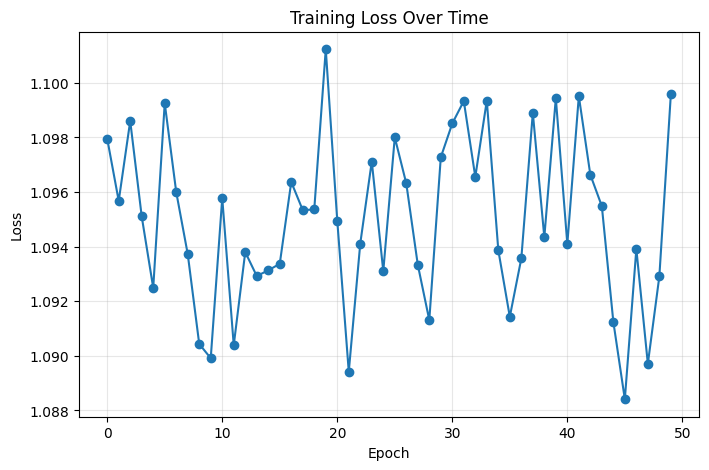

In [2]:
import jax
import jax.numpy as jnp
from jax import grad, jit, vmap, value_and_grad
from jax.nn import relu, softmax, log_softmax
import numpy as np
import matplotlib.pyplot as plt

# 1. Generate synthetic dataset
key = jax.random.PRNGKey(0)
n_samples = 200
n_features = 10
n_classes = 3

key, subkey1, subkey2 = jax.random.split(key, 3)
X = jax.random.normal(subkey1, (n_samples, n_features))
y = jax.random.randint(subkey2, (n_samples,), 0, n_classes)

# 2. Define neural network
def init_network_params(key, layer_sizes):
    """Initialize network parameters"""
    params = []
    for in_size, out_size in zip(layer_sizes[:-1], layer_sizes[1:]):
        key, subkey = jax.random.split(key)
        w = jax.random.normal(subkey, (in_size, out_size)) * 0.01
        b = jnp.zeros(out_size)
        params.append({'w': w, 'b': b})
    return params

layer_sizes = [n_features, 64, 32, n_classes]
params = init_network_params(key, layer_sizes)

# 3. Forward pass
def forward(params, x):
    """Forward pass through network"""
    for i, layer_params in enumerate(params[:-1]):
        x = jnp.dot(x, layer_params['w']) + layer_params['b']
        x = relu(x)

    # Output layer
    x = jnp.dot(x, params[-1]['w']) + params[-1]['b']
    return log_softmax(x)

# 4. Loss function
def loss_fn(params, x, y):
    logits = forward(params, x)
    return -logits[y]  # Cross-entropy

# 5. Batched loss and gradient
def batch_loss(params, xs, ys):
    losses = vmap(lambda x, y: loss_fn(params, x, y))(xs, ys)
    return jnp.mean(losses)

@jit
def train_step(params, xs, ys, learning_rate):
    loss, grads = value_and_grad(batch_loss)(params, xs, ys)

    # Update parameters
    new_params = []
    for layer_params, layer_grads in zip(params, grads):
        new_layer = {
            'w': layer_params['w'] - learning_rate * layer_grads['w'],
            'b': layer_params['b'] - learning_rate * layer_grads['b']
        }
        new_params.append(new_layer)

    return new_params, loss

# 6. Accuracy function
def accuracy(params, xs, ys):
    predictions = vmap(lambda x: jnp.argmax(forward(params, x)))(xs)
    return jnp.mean(predictions == ys)

# 7. Training loop
learning_rate = 0.1
batch_size = 32
n_epochs = 50
losses = []

for epoch in range(n_epochs):
    # Shuffle data
    indices = np.random.permutation(len(X))

    epoch_loss = 0
    n_batches = 0

    for i in range(0, len(X), batch_size):
        batch_idx = indices[i:i+batch_size]
        xs = X[batch_idx]
        ys = y[batch_idx]

        params, loss = train_step(params, xs, ys, learning_rate)
        epoch_loss += loss
        n_batches += 1

    avg_loss = epoch_loss / n_batches
    losses.append(float(avg_loss))

    if (epoch + 1) % 10 == 0:
        train_acc = accuracy(params, X, y)
        print(f"Epoch {epoch+1}: Loss = {avg_loss:.4f}, Accuracy = {float(train_acc):.4f}")

# 8. Results
final_acc = accuracy(params, X, y)
print(f"\nFinal Training Accuracy: {float(final_acc):.4f}")

# Visualization
plt.figure(figsize=(8, 5))
plt.plot(losses, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Over Time')
plt.grid(True, alpha=0.3)
plt.savefig('neural_network_loss.png')
plt.show()